# Ada Boosting

In [2]:
import pandas as pd

df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
X = df.iloc[:, [2, 3]].values    # Age, EstimatedSalary
y = df.iloc[:, -1].values


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

base_model = DecisionTreeClassifier(max_depth=1)

classifier = AdaBoostClassifier(estimator=base_model, n_estimators=50,
                                learning_rate=1.0, random_state=42)

In [6]:
classifier.fit(X_train, y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [10]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

y_pred = classifier.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred) )

Accuracy: 0.8875
Confusion Matrix:
 [[48  4]
 [ 5 23]]


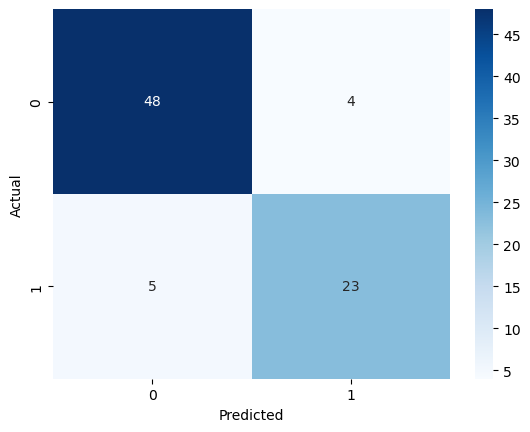

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()